In [11]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import numpy as np
import mne
# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
# Notice we are inside of src directory
!ls -la

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [12]:
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


(671600, 23)
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Creating RawArray with float64 data, n_channels=21, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
Successfully created Raw object
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-12 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-12 dB cutoff frequency: 45.00 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) re

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


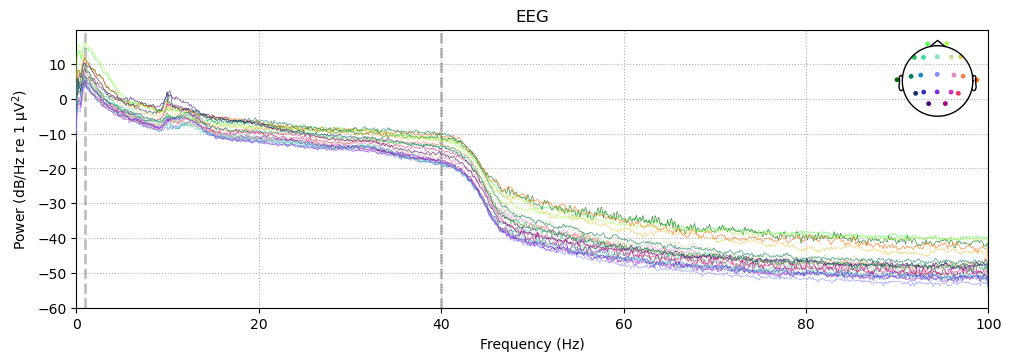

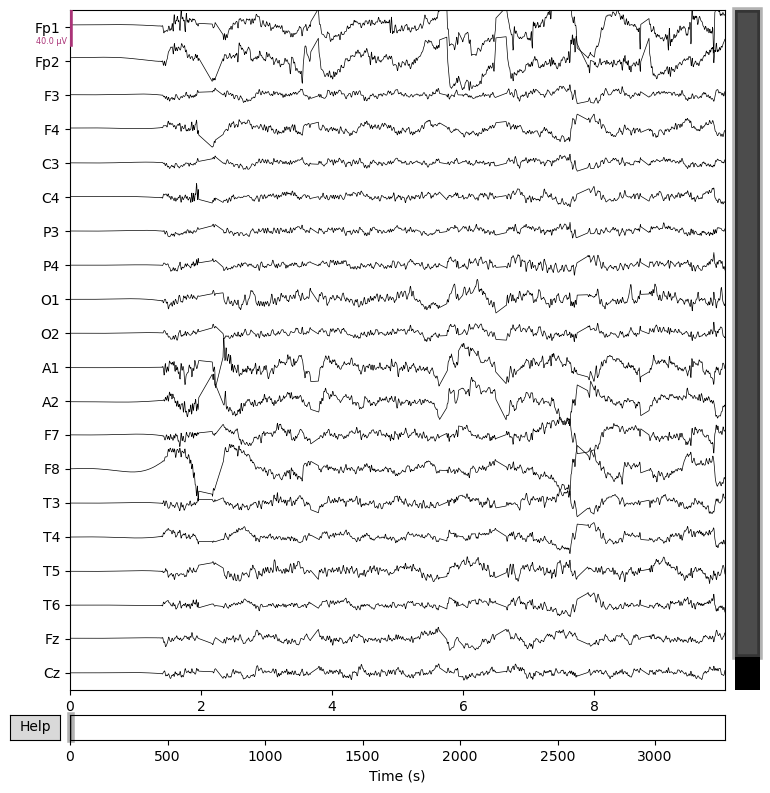

In [13]:
metadata, data = u.read_file(files[0])
print(data.shape)
raw=u.read_file_to_raw(files[0])
p.preprocess_eeg(raw)
raw.compute_psd().plot()
_=raw.plot()

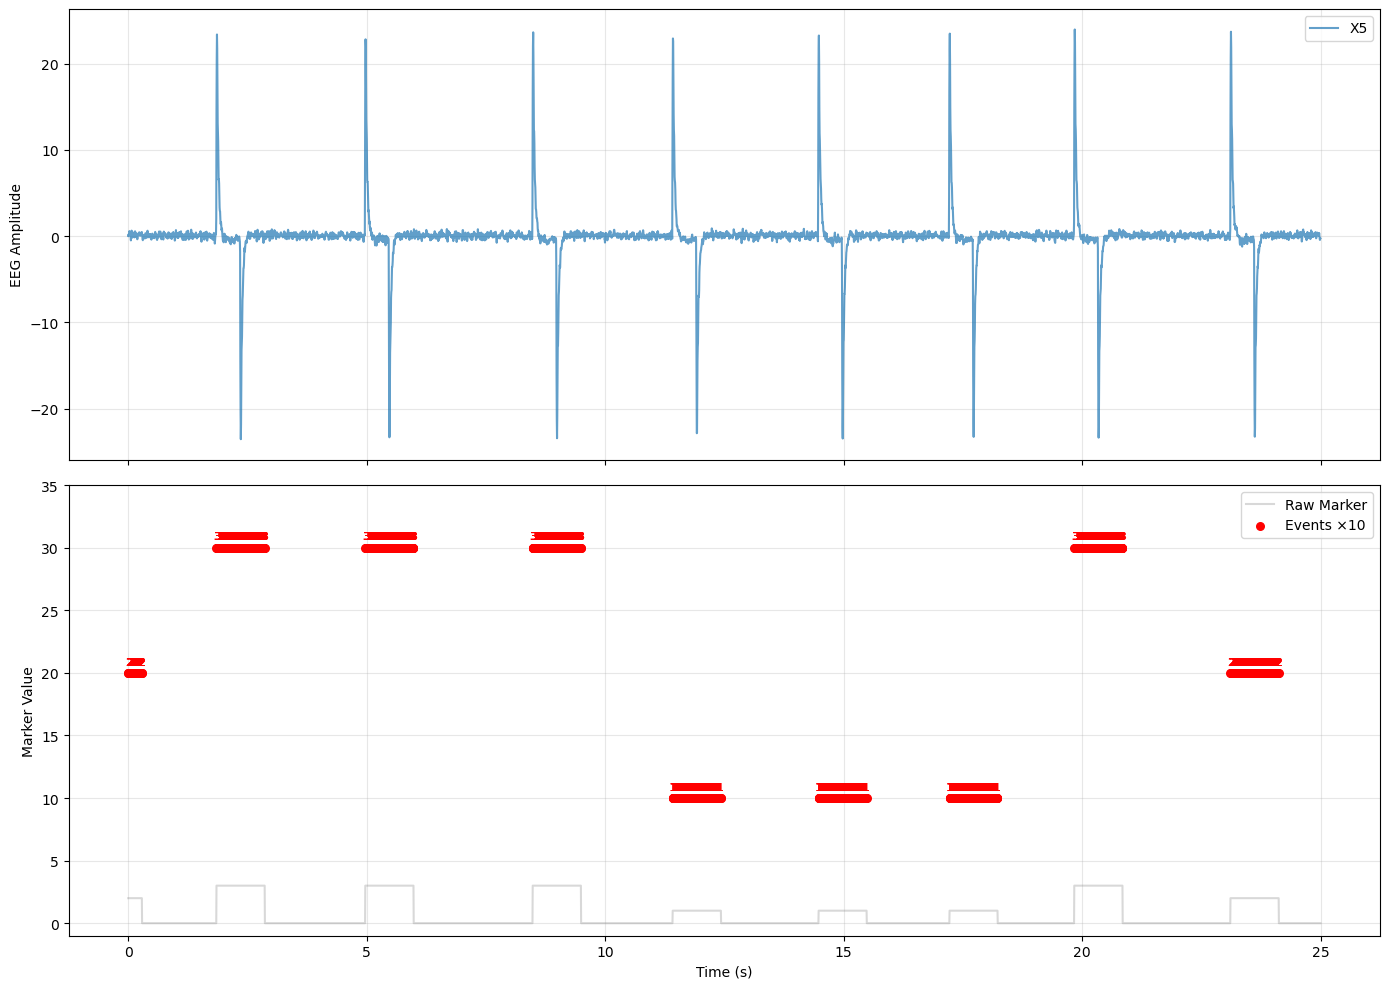

Events in this window: {1: 607, 2: 261, 3: 812}
{0: 476168, 1: 61490, 2: 69202, 3: 64740}


In [14]:
u.plot_eeg_signals_with_events(data, first_sample=50000, window_size=5000, freq=metadata["sampling_freq"][0], channels=[ "X5","marker"])
# Count all unique values
unique_values, counts = np.unique(data["marker"], return_counts=True)
print(dict(zip(unique_values, counts)))


In [16]:
events = u.find_events_from_marker(data["marker"], metadata["sampling_freq"][0])
epochs = mne.Epochs(
        raw=raw,  # You might need to create a Raw object first
        events=events,
        tmin= -0.1,  # Start before event
        tmax= +0.5,      # End after event
        baseline=(None, 0),       # Baseline correction
        preload=True
    )
df = u.epochs_to_polars(epochs)


Not setting metadata
1920 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1920 events and 121 original time points ...


0 bad epochs dropped


In [19]:
import utils.models as m
importlib.reload(m)
!ls -la

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [22]:
C = metadata["channels"][0] # number of EEG channels
T = 121 # number of time samples
N = len( np.unique(data["marker"]))   # number of classes

model = m.convolutional_model(C=C, T=T, N=N)

# The model expects input shape: (1, 64, 512)
print(model.input_shape)

ValueError: Exception encountered when calling DepthwiseConv2D.call().

[1mComputed output size would be negative. Received `inputs shape=(None, 1, 22, 8)`, `kernel shape=(22, 1, 8, 16)`, `dilation_rate=[1 1]`.[0m

Arguments received by DepthwiseConv2D.call():
  • args=('<KerasTensor shape=(None, 1, 22, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>',)
  • kwargs=<class 'inspect._empty'>